In [131]:

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



# Q4 Results Analysis

This section analyzes the results produced in **Q4 – Training Set Size Analysis**.

The goal is to investigate how the amount of available training data affects fraud-detection performance and determine the point at which additional data provides diminishing returns.

Based on the conclusions from Questions 1–3, **Random Forest** was selected as the primary model and evaluated under different training-set sizes.

The analysis focuses on:

1. Classification performance.
2. Effect of SMOTE-Tomek balancing.
3. Feature-importance stability.
4. SHAP stability.
5. Saturation point detection.

---



## Load Experiment Results

Load the evaluation results and feature-analysis files generated during Q4.


In [132]:

current_path = Path.cwd()

while current_path.name != "MachineLearningProject":
    current_path = current_path.parent

PROJECT_ROOT = current_path

q4_results = pd.read_csv(
    PROJECT_ROOT / "out" / "Q4_results.csv"
)

q4_features = pd.read_csv(
    PROJECT_ROOT / "out" / "Q4_features.csv"
)

print(f"Results rows: {len(q4_results)}")
print(f"Feature rows: {len(q4_features)}")

q4_results = q4_results \
    .query("train_size != 'Default'") \
    .query("threshold_mode != 'recall'")

q4_results.head()


Results rows: 38
Feature rows: 19


,train_size,train_samples,balancing,threshold_mode,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
4,1%,2278,NaN,default,0.999017,0.808824,0.561224,0.662651,0.937465,0.683931,56851,13,43,55
6,2%,4556,NaN,default,0.998999,0.815385,0.540816,0.650307,0.937124,0.667346,56852,12,45,53
8,2%,8812,SMOTE_Tomek,default,0.999228,0.837500,0.683673,0.752809,0.936415,0.774662,56851,13,31,67
10,5%,11392,NaN,default,0.999298,0.829545,0.744898,0.784946,0.957535,0.728781,56849,15,25,73
12,5%,21314,SMOTE_Tomek,default,0.999350,0.858824,0.744898,0.797814,0.956508,0.792702,56852,12,25,73



## Dataset Overview

Inspect the structure of the generated experiment results before performing any analysis.


In [133]:

q4_results.info()

q4_results.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 4 to 36
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   train_size       17 non-null     object 
 1   train_samples    17 non-null     int64  
 2   balancing        8 non-null      object 
 3   threshold_mode   17 non-null     object 
 4   accuracy         17 non-null     float64
 5   precision        17 non-null     float64
 6   recall           17 non-null     float64
 7   f1               17 non-null     float64
 8   roc_auc          17 non-null     float64
 9   pr_auc           17 non-null     float64
 10  true_negatives   17 non-null     int64  
 11  false_positives  17 non-null     int64  
 12  false_negatives  17 non-null     int64  
 13  true_positives   17 non-null     int64  
dtypes: float64(6), int64(5), object(3)
memory usage: 2.0+ KB


,train_samples,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
count,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000
mean,122891.882353,0.999351,0.852272,0.755702,0.798160,0.952464,0.801199,56851.000000,13.000000,23.941176,74.058824
std,128395.945013,0.000167,0.051670,0.089865,0.062768,0.010757,0.068560,5.220153,5.220153,8.806749,8.806749
min,2278.000000,0.998999,0.792079,0.540816,0.650307,0.936415,0.667346,56843.000000,4.000000,14.000000,53.000000
25%,21314.000000,0.999298,0.815385,0.744898,0.784946,0.942583,0.774662,56846.000000,11.000000,19.000000,73.000000
50%,89488.000000,0.999350,0.837500,0.795918,0.810256,0.952698,0.828664,56851.000000,13.000000,20.000000,78.000000
75%,182276.000000,0.999438,0.875000,0.806122,0.835821,0.958050,0.858206,56853.000000,18.000000,25.000000,79.000000
max,408230.000000,0.999579,0.951220,0.857143,0.866667,0.970369,0.869090,56860.000000,21.000000,45.000000,84.000000



# Training Size Performance Analysis

The purpose of this section is to understand how performance changes as additional training data becomes available.

Because fraud detection suffers from severe class imbalance, we focus primarily on:

- Recall
- Precision
- F1 Score
- PR-AUC
- ROC-AUC

A saturation point is expected once adding more data yields only marginal improvements.



## Average Performance By Training Size

Aggregate all configurations by training size to observe the overall trend.


In [134]:
metrics = [
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "roc_auc"
]

performance_summary = (
    q4_results
    .groupby(["train_size", "balancing"])[metrics]
    .mean()
    .reset_index()
)

performance_summary["train_size_numeric"] = (
    performance_summary["train_size"]
    .astype(str)
    .str.rstrip("%")
    .astype(float)
)

performance_summary = (
    performance_summary
    .sort_values("train_size_numeric")
    .drop(columns="train_size_numeric")
)

performance_summary

,train_size,balancing,precision,recall,f1,pr_auc,roc_auc
1,2%,SMOTE_Tomek,0.837500,0.683673,0.752809,0.774662,0.936415
4,5%,SMOTE_Tomek,0.858824,0.744898,0.797814,0.792702,0.956508
0,10%,SMOTE_Tomek,0.838710,0.795918,0.816754,0.700496,0.950870
2,20%,SMOTE_Tomek,0.806122,0.806122,0.806122,0.796292,0.965369
3,40%,SMOTE_Tomek,0.814433,0.806122,0.810256,0.828664,0.970369
5,60%,SMOTE_Tomek,0.815534,0.857143,0.835821,0.858569,0.955076
6,80%,SMOTE_Tomek,0.820000,0.836735,0.828283,0.858206,0.959348
7,90%,SMOTE_Tomek,0.792079,0.816327,0.804020,0.869090,0.969670



## Performance Metrics vs Training Size (SMOTE-Tomek)

This graph presents the evolution of the main performance metrics as the training set size increases while applying the SMOTE-Tomek balancing technique.

The graph allows us to evaluate how additional training data affects the fraud detection model and identify the point at which performance improvements begin to stabilize.

Displayed metrics:
- Recall
- Precision
- F1-Score
- PR-AUC
- ROC-AUC


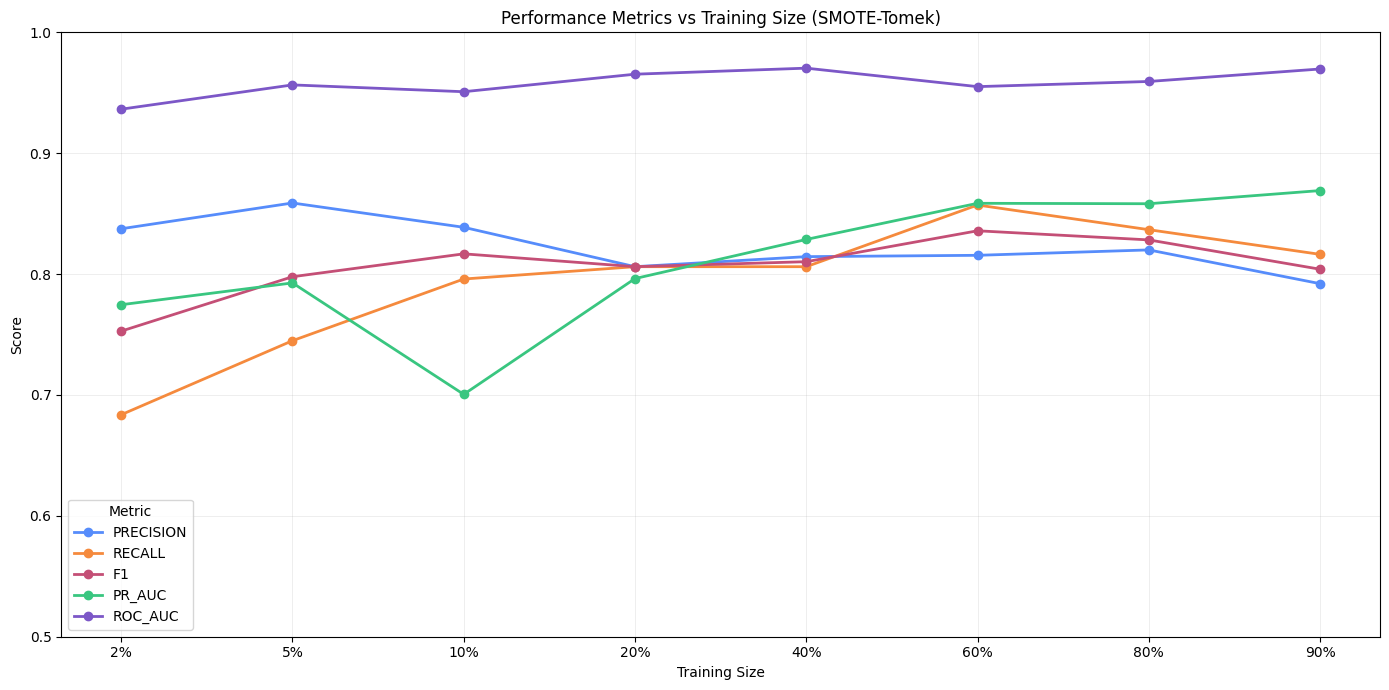

In [135]:

metrics = ["precision", "recall", "f1", "pr_auc", "roc_auc"]

plot_data = performance_summary[
    performance_summary["balancing"] == "SMOTE_Tomek"
]

plt.figure(figsize=(14, 7))

for metric in metrics:
    plt.plot(
        plot_data["train_size"],
        plot_data[metric],
        marker="o",
        linewidth=2,
        label=metric.upper()
    )

plt.title("Performance Metrics vs Training Size (SMOTE-Tomek)")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()



## Performance Metrics vs Training Size (No Balancing)

This graph shows the performance of the Random Forest model using the original imbalanced dataset without applying any balancing technique.

The purpose is to examine how model performance changes as more training data becomes available and to compare these results with the balanced SMOTE-Tomek configuration.


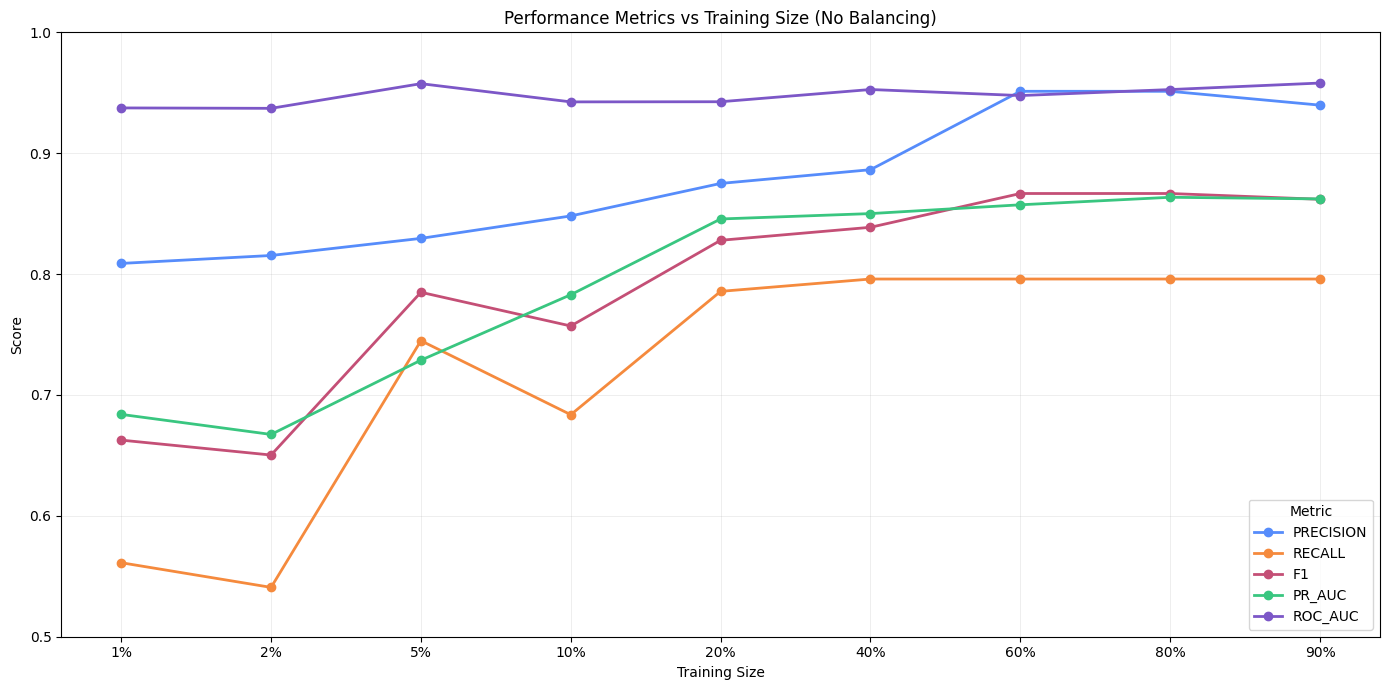

In [136]:

metrics = ["precision", "recall", "f1", "pr_auc", "roc_auc"]

none_data = (
    q4_results[q4_results["balancing"].isna()]
    .copy()
)

none_data["train_size_num"] = (
    none_data["train_size"]
    .str.replace("%", "", regex=False)
    .astype(int)
)

none_data = none_data.sort_values("train_size_num")

plt.figure(figsize=(14,7))

for metric in metrics:
    plt.plot(
        none_data["train_size"],
        none_data[metric],
        marker="o",
        linewidth=2,
        label=metric.upper()
    )

plt.title("Performance Metrics vs Training Size (No Balancing)")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()



# Effect of SMOTE-Tomek

This section examines whether balancing remains beneficial as more data becomes available.

The primary question:

Does balancing improve fraud-detection performance once large amounts of training data are available?


In [137]:

best_configs = (
    q4_results
    .sort_values(
        ["f1", "recall"],
        ascending=False
    )
)

best_configs.head(20)


,train_size,train_samples,balancing,threshold_mode,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
26,60%,136707,NaN,default,0.999579,0.951220,0.795918,0.866667,0.947699,0.857325,56860,4,20,78
30,80%,182276,NaN,default,0.999579,0.951220,0.795918,0.866667,0.952655,0.863550,56860,4,20,78
34,90%,205060,NaN,default,0.999561,0.939759,0.795918,0.861878,0.958050,0.862189,56859,5,20,78
22,40%,91138,NaN,default,0.999473,0.886364,0.795918,0.838710,0.952698,0.850050,56854,10,20,78
28,60%,272038,SMOTE_Tomek,default,0.999421,0.815534,0.857143,0.835821,0.955076,0.858569,56845,19,14,84
32,80%,362916,SMOTE_Tomek,default,0.999403,0.820000,0.836735,0.828283,0.959348,0.858206,56846,18,16,82
18,20%,45569,NaN,default,0.999438,0.875000,0.785714,0.827957,0.942583,0.845595,56853,11,21,77
16,10%,43888,SMOTE_Tomek,default,0.999386,0.838710,0.795918,0.816754,0.950870,0.700496,56849,15,20,78
24,40%,180716,SMOTE_Tomek,default,0.999350,0.814433,0.806122,0.810256,0.970369,0.828664,56846,18,19,79
20,20%,89488,SMOTE_Tomek,default,0.999333,0.806122,0.806122,0.806122,0.965369,0.796292,56845,19,19,79



### Conclusion

Increasing the training set size leads to a clear improvement in fraud detection performance, particularly when moving from very small datasets to medium-sized training sets. The largest gains are observed in Recall, F1-Score, PR-AUC, and ROC-AUC, indicating that the model becomes significantly more effective at identifying fraudulent transactions as more data becomes available.

However, beyond approximately **40%-60%** of the available training data, most performance metrics begin to stabilize and only minor improvements are observed. This suggests that the model has already learned the dominant fraud patterns in the dataset and has reached a practical performance saturation point.

### Effect of SMOTE-Tomek – Conclusion

SMOTE-Tomek provides the greatest benefit when training data is limited. At **2%** of the training data, Recall improved from **54.1%** to **68.4%**, while F1-Score increased from **65.0%** to **75.3%**, demonstrating a substantial improvement in fraud detection capability.

As the training set grows, the performance gap between the balanced and unbalanced configurations gradually decreases. From approximately **40%-60%** of the available data, both approaches achieve similar overall performance, indicating that the model can learn the underlying fraud patterns from the real data alone. Therefore, SMOTE-Tomek is most useful in data-scarce scenarios, while its contribution becomes less significant as the amount of training data increases.



# Feature Importance Stability Analysis

An effective fraud-detection system should identify approximately the same important features regardless of training-set size.

We now examine how stable the feature rankings remain throughout the experiment.
`


In [138]:
q4_features.head()

,train_size,balancing,top_features,shap_stats
0,Default,NaN,"[{'feature': 'V17', 'importance': 0.1703246439...",{'shap_importance': V17 0.002883\nV14 0....
1,Default,SMOTE_Tomek,"[{'feature': 'V14', 'importance': 0.2109446250...",{'shap_importance': V14 0.086936\nV4 0....
2,1%,NaN,"[{'feature': 'V14', 'importance': 0.1996598504...",{'shap_importance': V10 0.001099\nV17 0....
3,2%,NaN,"[{'feature': 'V17', 'importance': 0.1467757927...",{'shap_importance': V17 0.001220\nV10 0....
4,2%,SMOTE_Tomek,"[{'feature': 'V14', 'importance': 0.2190998571...",{'shap_importance': V14 0.132932\nV10 0....


## Parse Feature Logs

In [139]:

import ast

q4_features["top_features"] = q4_features[
    "top_features"
].apply(ast.literal_eval)



## Most Frequent Top Features

Count how often each feature appears among the top-ranked features.


In [140]:

from collections import Counter

counter = Counter()

for feature_list in q4_features["top_features"]:

    for feature in feature_list:
        counter[
            feature["feature"]
        ] += 1

feature_stability = pd.DataFrame(
    counter.items(),
    columns=[
        "feature",
        "count"
    ]
)

feature_stability = feature_stability.sort_values(
    "count",
    ascending=False
)

feature_stability.head(15)


,feature,count
0,V17,19
1,V14,19
2,V12,19
3,V10,19
5,V11,19
7,V4,18
6,V9,16
4,V16,15
10,V3,14
9,V7,11


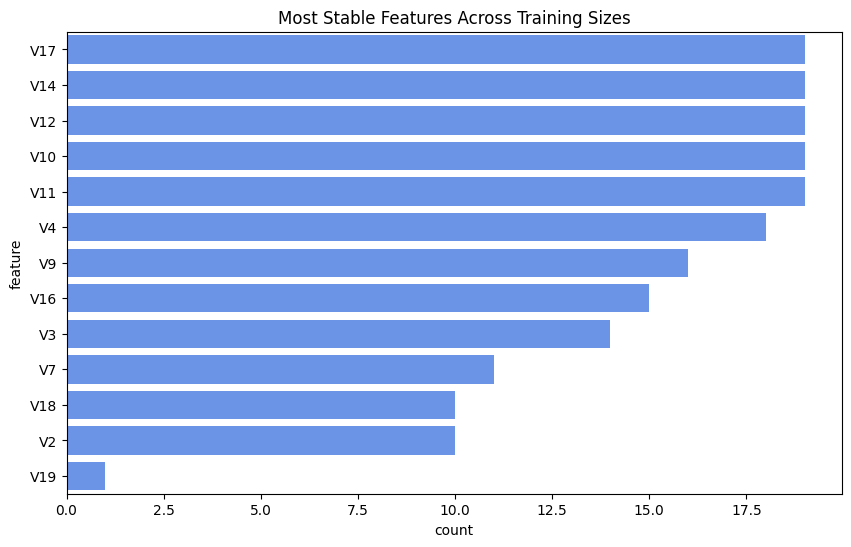

In [141]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_stability.head(15),
    x="count",
    y="feature"
)

plt.title(
    "Most Stable Features Across Training Sizes"
)

plt.show()



# SHAP Stability Analysis

SHAP explanations help determine whether the model continues to rely on the same decision signals as more training data becomes available.




/tmp/ipykernel_5045/1584190564.py:83: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  shap_df[


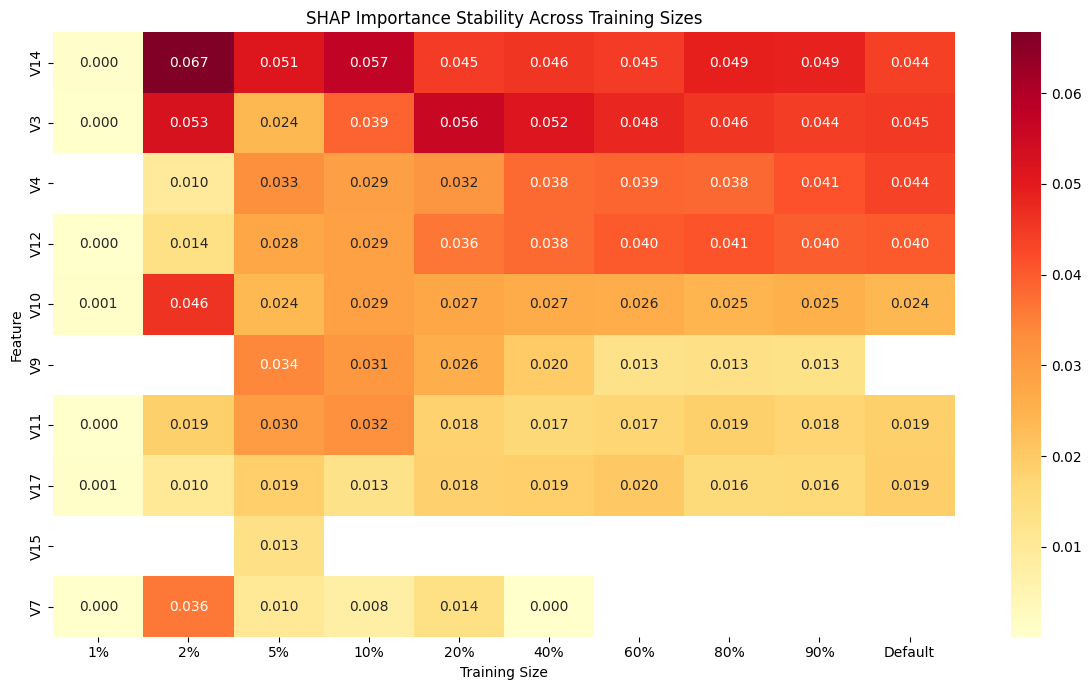

In [142]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import re

rows = []

for _, row in q4_features.iterrows():

    train_size = row["train_size"]

    shap_text = str(row["shap_stats"])

    match = re.search(
        r"shap_importance':(.*?)dtype:",
        shap_text,
        re.S
    )

    if not match:
        continue

    shap_block = match.group(1)

    values = {}

    for line in shap_block.split("\n"):
        line = line.strip()

        parts = line.split()

        if len(parts) >= 2:
            try:
                feature = parts[0]
                value = float(parts[-1])
                values[feature] = value
            except:
                pass

    for feature, value in values.items():
        rows.append(
            {
                "train_size": train_size,
                "feature": feature,
                "shap": value
            }
        )

shap_df = pd.DataFrame(rows)

# מיון גדלי הדאטה
size_order = [
    "1%",
    "2%",
    "5%",
    "10%",
    "20%",
    "40%",
    "60%",
    "80%",
    "90%",
    "Default"
]

shap_df["train_size"] = pd.Categorical(
    shap_df["train_size"],
    categories=size_order,
    ordered=True
)

# Top 10 features overall
top_features = (
    shap_df.groupby("feature")["shap"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

heatmap_data = (
    shap_df[
        shap_df["feature"].isin(top_features)
    ]
    .pivot_table(
        index="feature",
        columns="train_size",
        values="shap",
        aggfunc="mean"
    )
)

heatmap_data = heatmap_data.loc[
    heatmap_data.mean(axis=1)
    .sort_values(ascending=False)
    .index
]

plt.figure(figsize=(12, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlOrRd",
    fmt=".3f"
)

plt.title(
    "SHAP Importance Stability Across Training Sizes"
)

plt.xlabel("Training Size")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()



### SHAP Stability Analysis

The SHAP stability analysis shows that the model relies on a consistent set of features across different training sizes. Features such as **V14, V17, V10, and V12** remain among the most influential predictors throughout the experiment, while their relative importance changes only slightly as more training data becomes available.

This consistency indicates that the model learns stable fraud-related patterns rather than dataset-specific noise. Therefore, increasing the training size improves performance, but does not significantly change the underlying decision logic of the model.



## Q4 Conclusion

The Q4 analysis demonstrates that both the amount of training data and the handling of class imbalance play an important role in fraud detection performance. As the training set size increases, the model achieves significant improvements in Recall, F1-Score, PR-AUC, and ROC-AUC, particularly when moving from very small datasets to medium-sized training sets. However, the results consistently indicate a performance saturation point around **40%-60%** of the available data, beyond which additional samples provide only marginal benefits.

The experiments also show that **SMOTE-Tomek** is especially valuable when training data is limited, substantially improving fraud detection performance at smaller dataset sizes. As more real training data becomes available, the difference between balanced and unbalanced configurations gradually decreases, suggesting that the model can effectively learn the fraud patterns directly from the data.

Finally, both the Feature Importance and SHAP analyses reveal a high degree of stability across all training sizes. Key features such as **V14, V17, V10, and V12** remain consistently influential, indicating that the model relies on the same underlying fraud-related patterns regardless of dataset size. This stability strengthens confidence in both the robustness and interpretability of the final model.

Overall, the results suggest that the Random Forest model learns stable and meaningful fraud patterns, reaches near-optimal performance with approximately **40%-60%** of the available training data, and benefits most from SMOTE-Tomek when operating in data-scarce scenarios.
